# Clustering on Feature Pairs (no PCA)

**Why this notebook?** In the previous clustering work (`Clustering.ipynb`, `Clustering_TimeSeries.ipynb`) we visualised clusters with **PCA**. The professors' objection is correct: PCA builds *new* axes (principal components) that are linear mixtures of the original traits, so a PCA scatter **hides which original features actually drive the grouping** and PCA implicitly assumes the components are independent directions of variance.

**The alternative requested:** instead of PCA, cluster on **exactly two original features at a time**. From the four traits

$$\big(\;\texttt{milk\_kg},\;\texttt{DIM},\;\texttt{parity},\;\texttt{AFC}\;\big)$$

there are $\binom{4}{2}=6$ pairs:

| # | feature A | feature B |
|---|-----------|-----------|
| 1 | milk_kg | DIM |
| 2 | milk_kg | parity |
| 3 | milk_kg | AFC |
| 4 | DIM | parity |
| 5 | DIM | AFC |
| 6 | parity | AFC |

**The key advantage:** when we cluster on 2 features, the 2-D scatter we plot **is the real feature space** (x = feature A, y = feature B). No PCA, no abstract components — every cluster boundary is read directly in the units of the two traits, so it is obvious *which* features separate the groups and how they are related.

This notebook only **reads** `../../../Thesis_Data/Final_Data/After_Processing.csv`. It does not modify any other file or notebook.

In [18]:
import os
from itertools import combinations

# Keep BLAS from oversubscribing cores (set before importing numpy).
N_JOBS = max(1, (os.cpu_count() or 2) - 1)
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, str(min(N_JOBS, 8)))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
SIL_SAMPLE = 50000          # silhouette is O(n^2) -> score on at most this many points
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# The four candidate features and their 6 pairwise combinations.
FEATURES = [ 'DIM', 'parity', 'AFC','protein_p', 'fat_p', 'SCS','milk_kg']
PAIRS = list(combinations(FEATURES, 2))
print(f'Using up to {N_JOBS} cores; silhouette sampled to {SIL_SAMPLE:,} points')
print('Feature pairs to cluster on:')
for i, p in enumerate(PAIRS, 1):
    print(f'  {i}. {p[0]:8s} + {p[1]}')

Using up to 7 cores; silhouette sampled to 50,000 points
Feature pairs to cluster on:
  1. DIM      + parity
  2. DIM      + AFC
  3. DIM      + protein_p
  4. DIM      + fat_p
  5. DIM      + SCS
  6. DIM      + milk_kg
  7. parity   + AFC
  8. parity   + protein_p
  9. parity   + fat_p
  10. parity   + SCS
  11. parity   + milk_kg
  12. AFC      + protein_p
  13. AFC      + fat_p
  14. AFC      + SCS
  15. AFC      + milk_kg
  16. protein_p + fat_p
  17. protein_p + SCS
  18. protein_p + milk_kg
  19. fat_p    + SCS
  20. fat_p    + milk_kg
  21. SCS      + milk_kg


In [19]:
# ---- Load (READ ONLY) ----
PATH = '../../../Thesis_Data/Final_Data/After_Processing.csv'
df = pd.read_csv(PATH, usecols=['Farm_Code', 'Animal_ID', 'parity', 'DIM', 'milk_kg', 'AFC','protein_p', 'fat_p', 'SCS'])

# AFC (age at first calving) is stored as a timedelta string e.g. '870 days' -> numeric days.
if df['AFC'].dtype == object:
    df['AFC'] = pd.to_timedelta(df['AFC']).dt.days

df = df.dropna(subset=FEATURES)
df = df[(df['milk_kg'] > 0) & (df['DIM'].between(1, 365))]
print(f'Loaded {len(df):,} records | {df["Animal_ID"].nunique():,} animals | {df["Farm_Code"].nunique():,} farms')
df[FEATURES].describe().round(2)

Loaded 1,645,883 records | 91,221 animals | 316 farms


,DIM,parity,AFC,protein_p,fat_p,SCS,milk_kg
count,"1,645,883.000","1,645,883.000","1,645,883.000","1,645,883.000","1,645,883.000","1,645,883.000","1,645,883.000"
mean,140.990,2.720,"1,842.170",4.710,8.010,3.150,9.340
std,84.930,1.870,851.210,0.430,1.840,1.720,3.570
min,1.000,1.000,713.000,2.670,1.600,-2.060,0.400
25%,70.000,1.000,"1,153.000",4.420,6.850,1.910,6.900
50%,133.000,2.000,"1,623.000",4.690,8.010,2.960,9.000
75%,203.000,4.000,"2,283.000",4.980,9.160,4.210,11.600
max,365.000,13.000,"5,940.000",6.680,15.050,10.730,26.500


## Build the feature tables

We run the pair-clustering at two levels (same idea as the earlier notebook, just without PCA):

* **Per animal** — one row per buffalo (lifetime aggregates). `milk_kg` and `DIM` are averaged, `parity` is the maximum reached, `AFC` is the age at first calving (constant per animal). This is the most interpretable level.
* **Per test-day record** — the raw rows (~1.6M). Heavier, but shows the full within-lactation spread.

Both tables carry all four candidate features so any of the 6 pairs can be selected.

In [20]:
# --- Per-animal aggregates ---
df_animal = (
    df.groupby('Animal_ID')
      .agg(milk_kg=('milk_kg', 'mean'),
           DIM=('DIM', 'mean'),
           parity=('parity', 'max'),
           AFC=('AFC', 'min'),          # age at FIRST calving -> the smallest value seen
           protein_p = ('protein_p','mean'),
           fat_p = ('fat_p','mean'),
           SCS = ('SCS', 'mean'),
           n_records=('milk_kg', 'size'))
      .reset_index()
)

# --- Per test-day record (raw rows) ---
df_record = df.reset_index(drop=True)

print(f'Per animal: {len(df_animal):,} rows')
print(f'Per record: {len(df_record):,} rows')
df_animal.head()

Per animal: 91,221 rows
Per record: 1,645,883 rows


,Animal_ID,milk_kg,DIM,parity,AFC,protein_p,fat_p,SCS,n_records
0,ES020904991568,6.360,92.400,1,"1,260.000",4.870,7.172,3.798,5
1,ES070904726446,5.843,96.000,2,"1,440.000",4.654,6.687,5.074,7
2,ES070904726457,3.940,144.400,1,"1,367.000",4.588,7.604,5.016,5
3,ES070904991552,7.431,115.385,2,"1,155.000",4.788,7.308,3.232,13
4,ES090904710673,3.950,116.417,2,"1,380.000",4.683,8.027,4.153,12


## Pair-clustering helpers

`cluster_pair` does the whole job for one pair: standardise the two features (so each contributes equally), run K-Means, and **plot the scatter directly on the two real feature axes** with the cluster centroids marked. Because there are only two features there is *nothing to project* — what you see is exactly what was clustered.

`best_k_for_pair` sweeps `k` and returns the value with the highest silhouette, so each pair gets its own sensible number of clusters.

In [21]:
def _silhouette(X, labels):
    """Silhouette on a capped random sample (O(n^2) otherwise). Needs >=2 clusters."""
    if len(set(labels)) < 2:
        return float('nan')
    n = min(SIL_SAMPLE, len(X))
    return silhouette_score(X, labels, sample_size=n, random_state=RANDOM_STATE)


def best_k_for_pair(X, k_range=range(2, 9), sample=20000):
    """Pick k with the best silhouette for a 2-feature matrix."""
    Xs = X if len(X) <= sample else X[np.random.choice(len(X), sample, replace=False)]
    sils = []
    for k in k_range:
        lab = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(Xs)
        sils.append(silhouette_score(Xs, lab))
    return list(k_range)[int(np.argmax(sils))], max(sils)


def cluster_pair(frame, fa, fb, k=None, ax=None, plot_sample=30000):
    """K-Means on the single pair (fa, fb). Plots the clusters on the real feature axes.
    Returns (labels, silhouette, profile DataFrame)."""
    feats = [fa, fb]
    scaler = StandardScaler()
    X = scaler.fit_transform(frame[feats].values)

    if k is None:
        k, _ = best_k_for_pair(X)

    km = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit(X)
    labels = km.labels_
    sil = _silhouette(X, labels)

    # Centroids back in original (un-scaled) units for an interpretable plot.
    centroids = scaler.inverse_transform(km.cluster_centers_)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    idx = np.arange(len(frame))
    if len(idx) > plot_sample:
        idx = np.random.choice(idx, plot_sample, replace=False)
    ax.scatter(frame[fa].values[idx], frame[fb].values[idx],
               c=labels[idx], cmap='tab10', s=8, alpha=0.45)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=180,
               edgecolor='white', linewidth=1.5, zorder=5)
    ax.set(xlabel=fa, ylabel=fb, title=f'{fa} vs {fb}  (k={k}, sil={sil:.2f})')
    ax.grid(alpha=0.3)

    prof = frame.assign(cluster=labels).groupby('cluster')[feats].mean()
    prof['size'] = frame.assign(cluster=labels).groupby('cluster').size()
    return labels, sil, prof

## Level 1 — Per animal: all 6 feature pairs

First a quick overview: cluster each of the 6 pairs (k chosen automatically by silhouette) and show all six scatter plots together. Each panel's axes are the two real traits, so you can read straight off which pair separates the buffalo most cleanly.

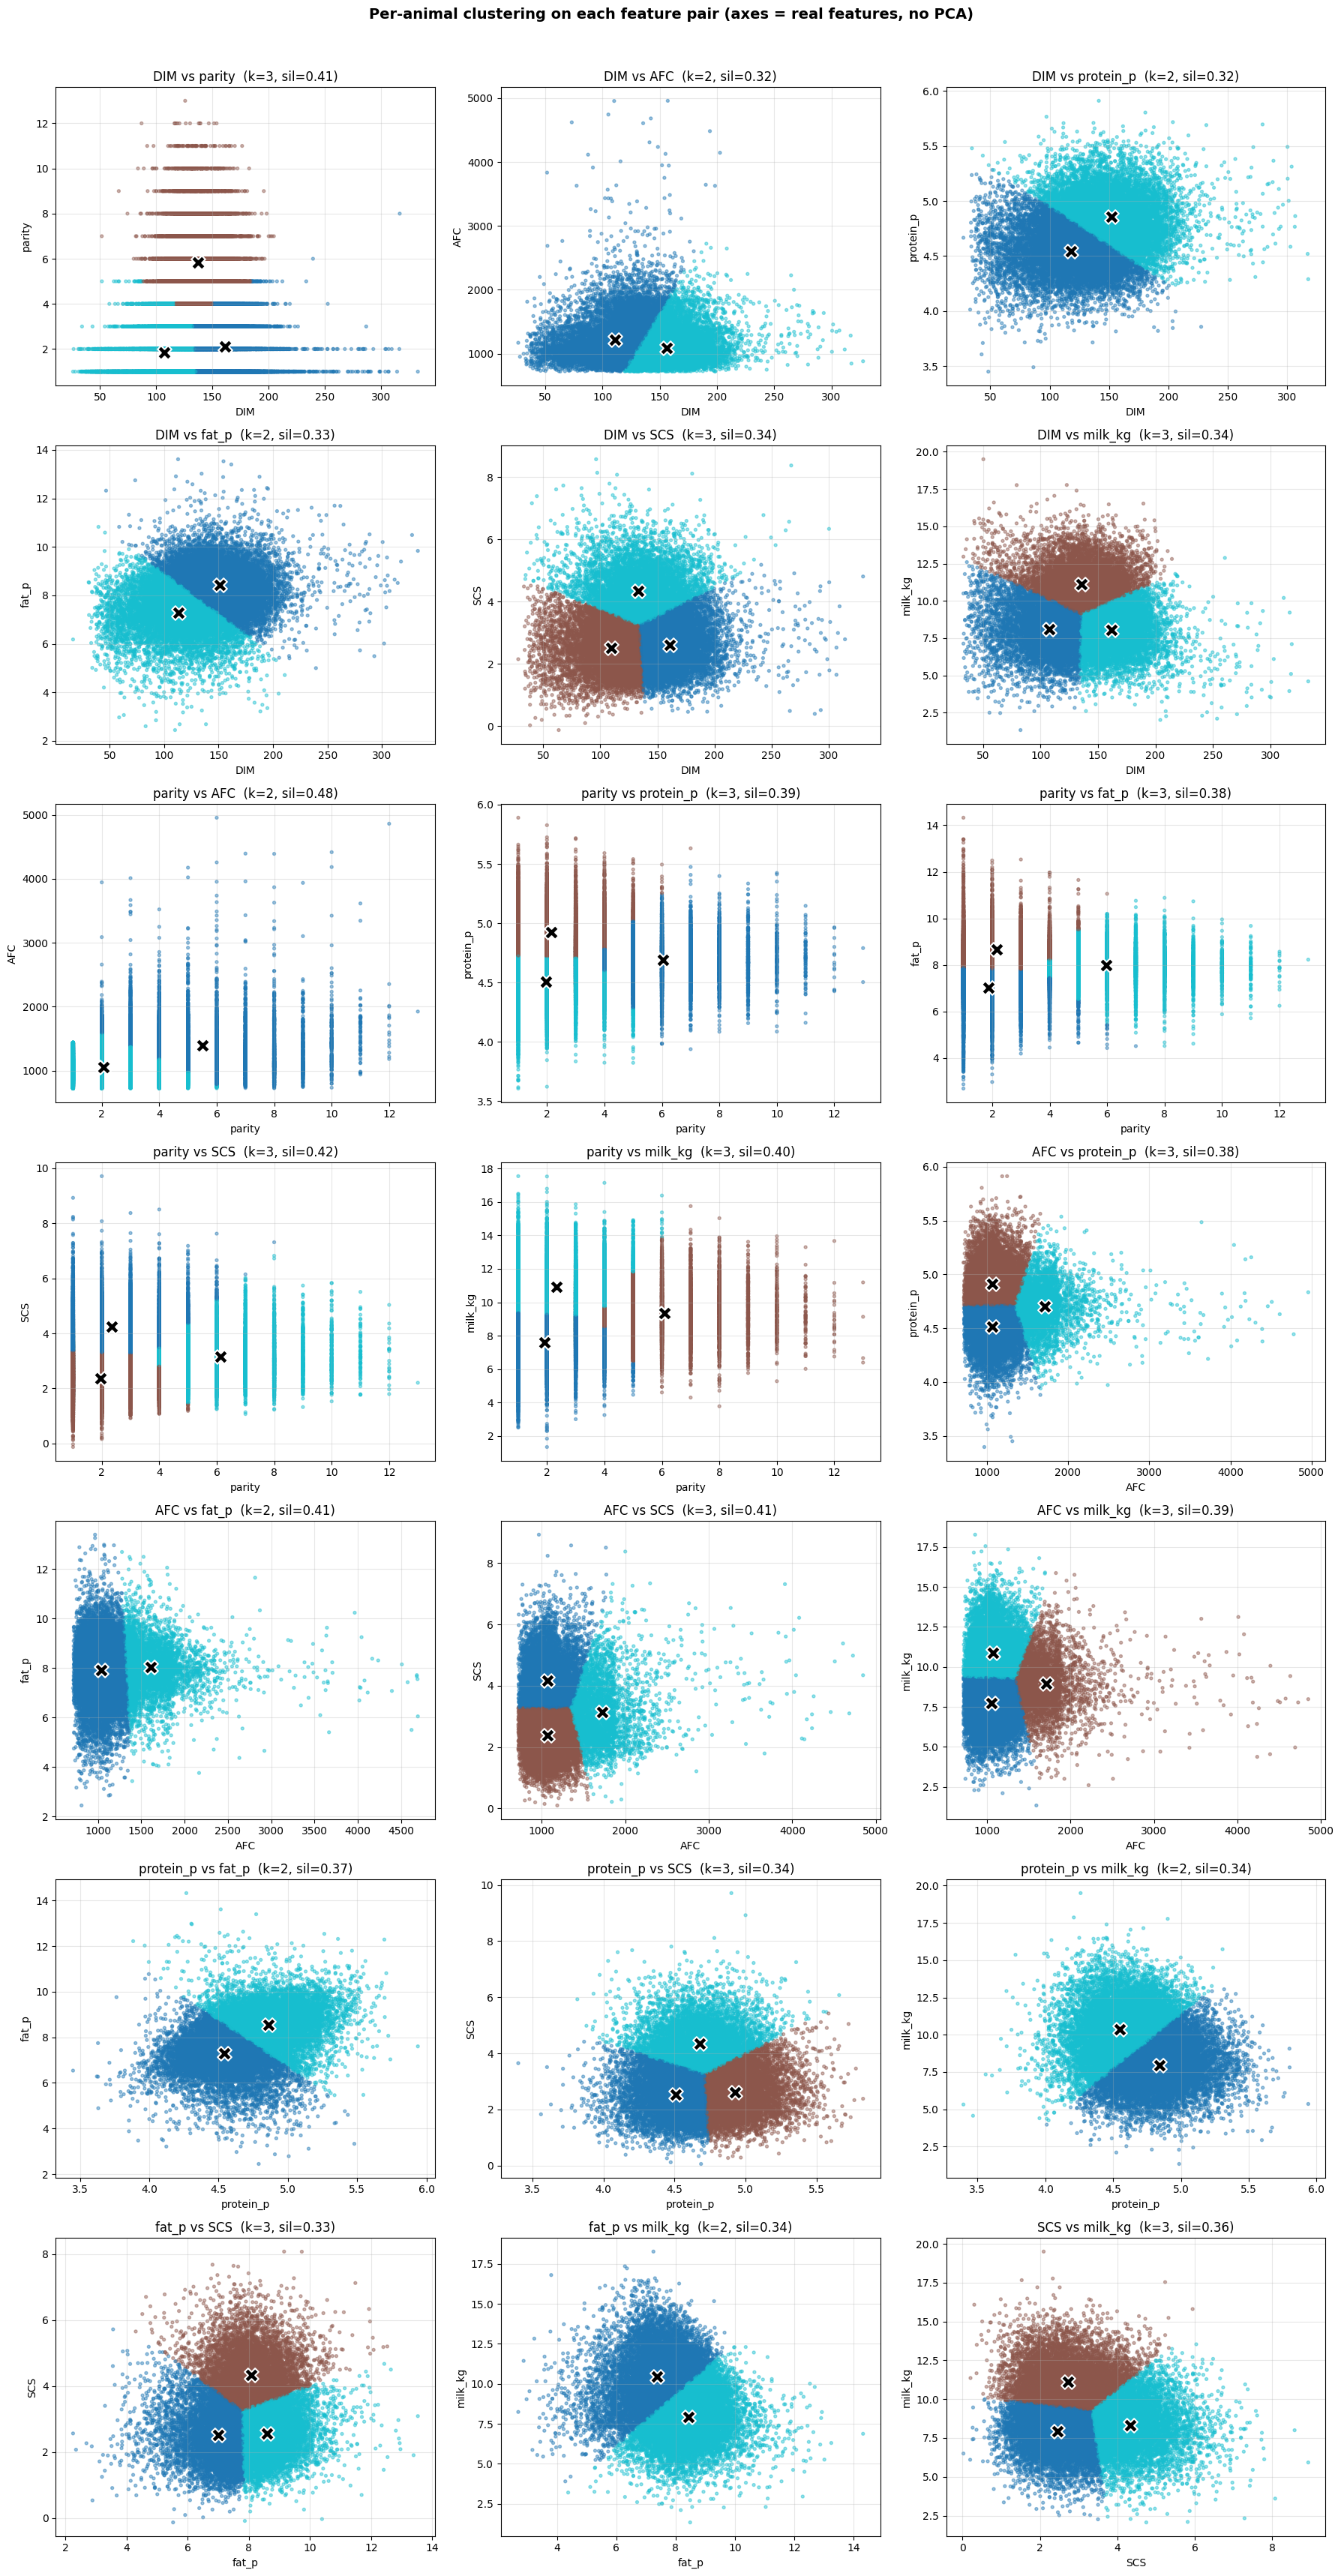

In [24]:
fig, axes = plt.subplots(7, 3, figsize=(18, 35))
results_animal = {}
for ax, (fa, fb) in zip(axes.ravel(), PAIRS):
    labels, sil, prof = cluster_pair(df_animal, fa, fb, ax=ax)
    results_animal[(fa, fb)] = (labels, sil, prof)
fig.suptitle('Per-animal clustering on each feature pair (axes = real features, no PCA)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [25]:
# Rank the pairs by silhouette: which two features give the cleanest grouping?
rank = (pd.DataFrame([(f'{a} + {b}', s) for (a, b), (_, s, _) in results_animal.items()],
                     columns=['feature_pair', 'silhouette'])
          .sort_values('silhouette', ascending=False)
          .reset_index(drop=True))
display(rank)

,feature_pair,silhouette
0,parity + AFC,0.485
1,parity + SCS,0.422
2,AFC + fat_p,0.415
3,DIM + parity,0.411
4,AFC + SCS,0.410
5,parity + milk_kg,0.400
6,AFC + milk_kg,0.392
7,parity + protein_p,0.390
8,parity + fat_p,0.382
9,AFC + protein_p,0.379


### Inspect one pair in detail

Set `PAIR` and (optionally) a fixed `K` below to look at any single combination closely, with its cluster profile table. Change `PAIR` to any of the 6 combinations and re-run.

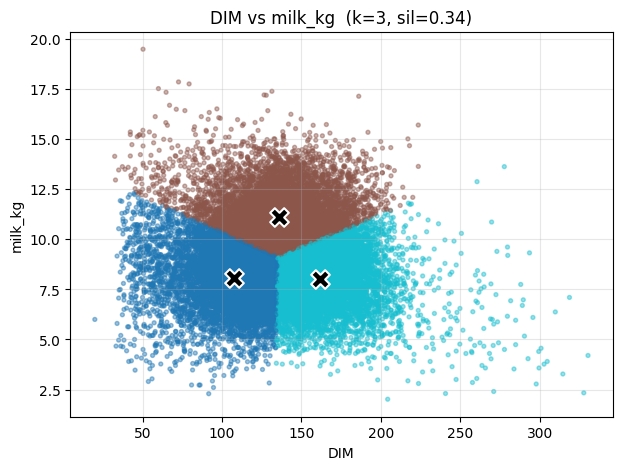

Pair ('DIM', 'milk_kg') | silhouette = 0.336


,DIM,milk_kg,size
cluster,,,
0,107.920,8.090,29826
1,135.880,11.120,30347
2,161.850,8.040,31048


In [26]:
# >>> choose the pair (and optionally force the number of clusters) <<<
PAIR = ('DIM','milk_kg')
K = None          # None = pick k automatically by silhouette; or set an integer e.g. 4

labels, sil, prof = cluster_pair(df_animal, PAIR[0], PAIR[1], k=K)
plt.show()
print(f'Pair {PAIR} | silhouette = {sil:.3f}')
display(prof.round(2))

### Optional — DBSCAN on a pair (density-based, finds the natural blobs + noise)

DBSCAN is especially natural here because, on just two standardised features, `eps` is a real distance in the plane. It finds dense regions automatically and labels sparse points as noise (`-1`). `eps` is taken at the 95th percentile of the k-distance curve as a starting heuristic.

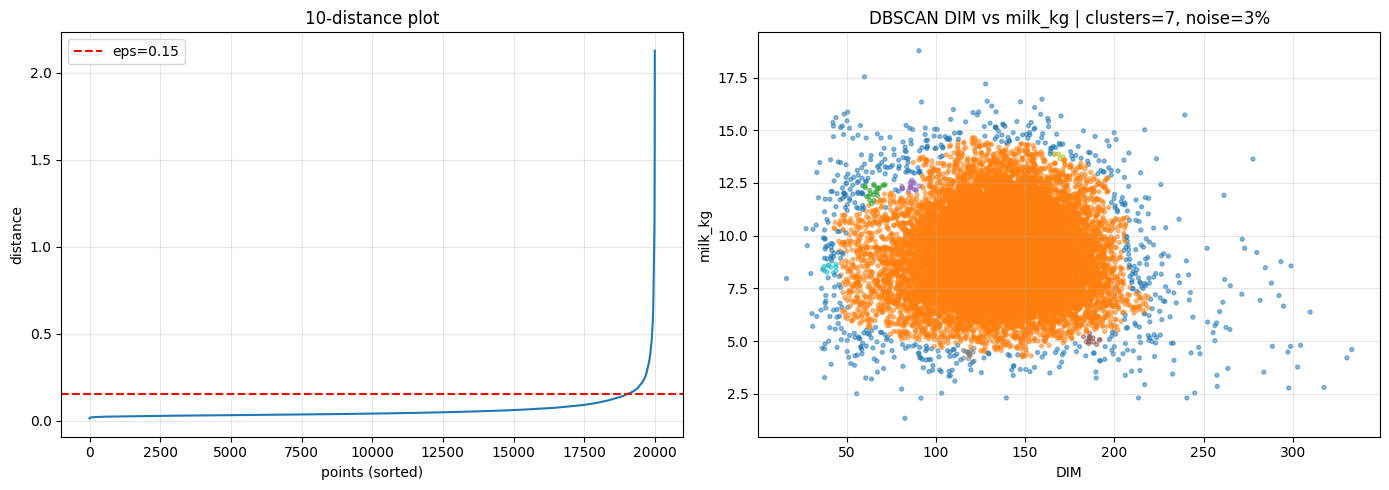

In [27]:
def dbscan_pair(frame, fa, fb, min_samples=10, sample=20000):
    feats = [fa, fb]
    X = StandardScaler().fit_transform(frame[feats].values)
    idx = np.arange(len(X)) if len(X) <= sample else np.random.choice(len(X), sample, replace=False)
    Xs = X[idx]
    nn = NearestNeighbors(n_neighbors=min_samples, n_jobs=N_JOBS).fit(Xs)
    dists = np.sort(nn.kneighbors(Xs)[0][:, -1])
    eps = np.percentile(dists, 95)
    labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=N_JOBS).fit_predict(Xs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).mean()

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(dists); ax[0].axhline(eps, color='red', ls='--', label=f'eps={eps:.2f}')
    ax[0].set(title=f'{min_samples}-distance plot', xlabel='points (sorted)', ylabel='distance')
    ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].scatter(frame[fa].values[idx], frame[fb].values[idx], c=labels, cmap='tab10', s=8, alpha=0.5)
    ax[1].set(xlabel=fa, ylabel=fb,
              title=f'DBSCAN {fa} vs {fb} | clusters={n_clusters}, noise={noise:.0%}')
    ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return idx, labels


# Example on the milk_kg + DIM pair; change to any pair.
_ = dbscan_pair(df_animal, 'DIM','milk_kg')

## Level 2 — Per test-day record: all 6 feature pairs

Same pair sweep on the full ~1.6M raw records. K-Means runs on all rows; the scatter is drawn on a random sample to stay readable. The axes are again the two real features.

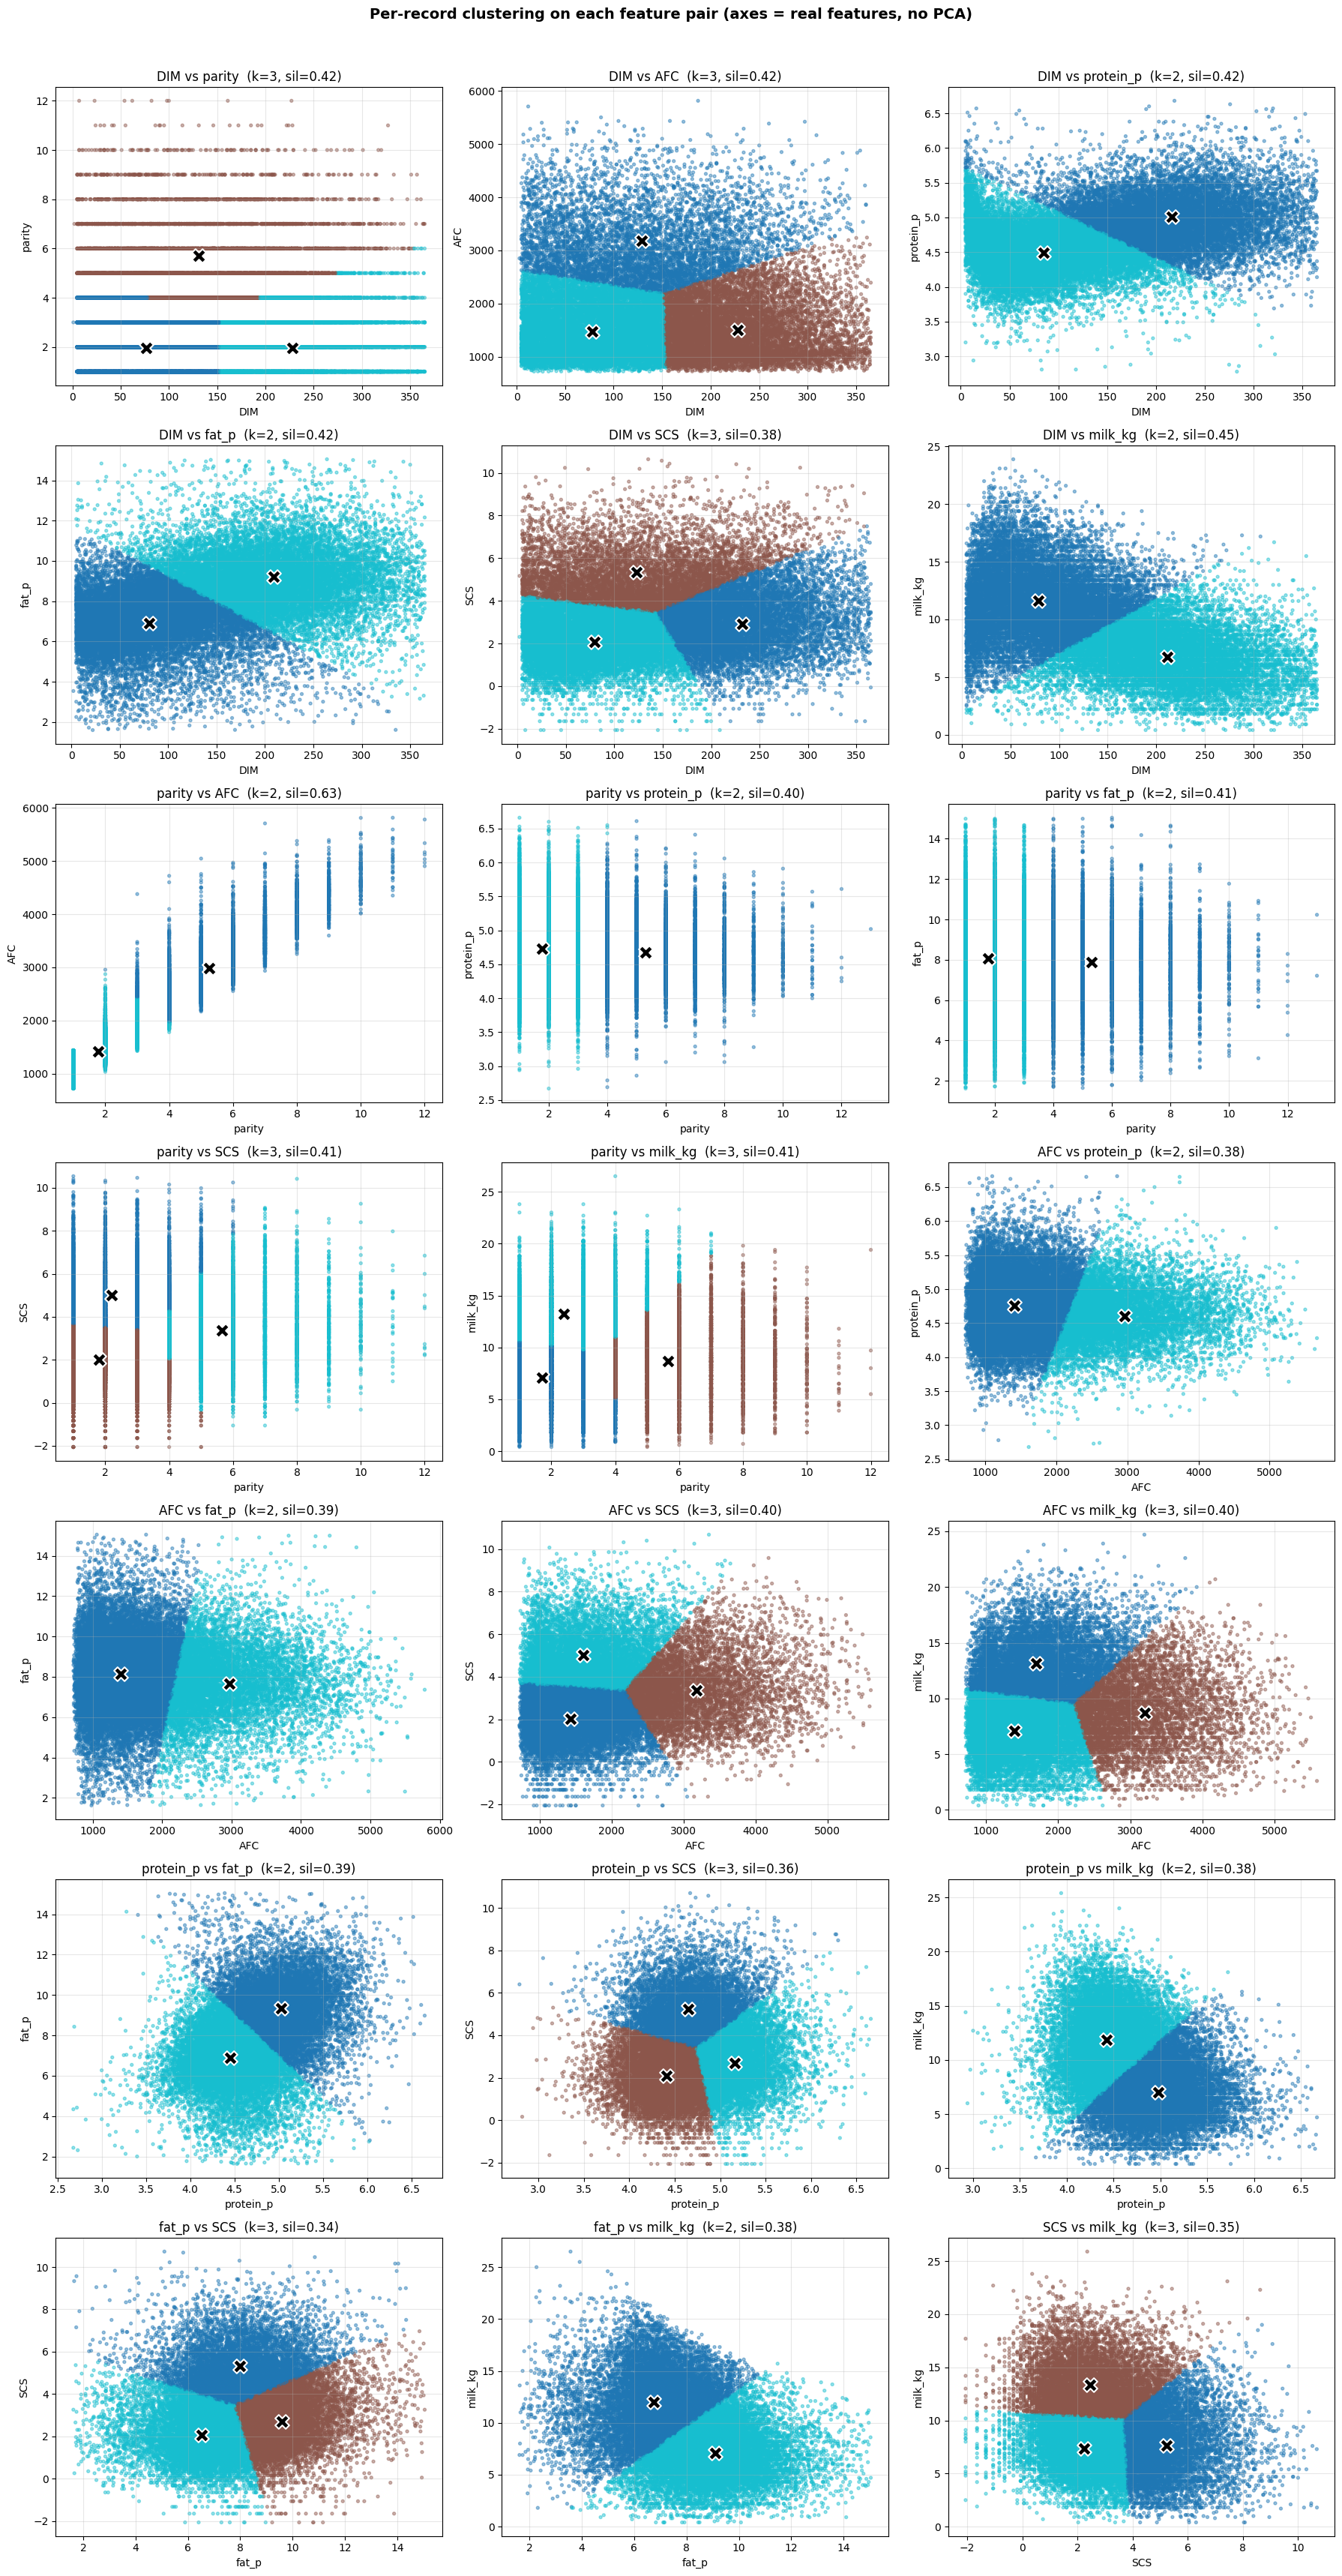

In [28]:
fig, axes = plt.subplots(7, 3, figsize=(18, 35))
results_record = {}
for ax, (fa, fb) in zip(axes.ravel(), PAIRS):
    labels, sil, prof = cluster_pair(df_record, fa, fb, ax=ax)
    results_record[(fa, fb)] = (labels, sil, prof)
fig.suptitle('Per-record clustering on each feature pair (axes = real features, no PCA)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [29]:
rank_rec = (pd.DataFrame([(f'{a} + {b}', s) for (a, b), (_, s, _) in results_record.items()],
                         columns=['feature_pair', 'silhouette'])
              .sort_values('silhouette', ascending=False)
              .reset_index(drop=True))
display(rank_rec)

,feature_pair,silhouette
0,parity + AFC,0.633
1,DIM + milk_kg,0.451
2,DIM + parity,0.425
3,DIM + fat_p,0.423
4,DIM + protein_p,0.419
5,DIM + AFC,0.415
6,parity + SCS,0.412
7,parity + milk_kg,0.408
8,parity + fat_p,0.405
9,AFC + SCS,0.403


## Notes

- **No PCA anywhere.** Every scatter is plotted on two original traits, so each cluster boundary is directly interpretable and you can see exactly how the two features relate within and across clusters — this is what the professors asked for.
- **Both features are standardised** before K-Means / DBSCAN so neither trait dominates purely because of its scale (e.g. `AFC` in hundreds of days vs `parity` 1–5).
- **k is chosen per pair** by the best silhouette, but you can force a specific `K` in the "inspect one pair" cell for a more interpretable grouping.
- **Caveat on `AFC`.** As stored, `AFC` is the age (in days) at calving; it is highly correlated with `parity`, so the `parity + AFC` pair will tend to separate along a single age/lactation-number axis. Compare its silhouette and scatter against the other pairs before reading much into it.
- To extend this to *three* features at a time, the same idea works with a 3-D scatter or a pairplot — but two-feature pairs keep every plot a plain, readable 2-D picture.